# Preparing the Köppen zone polygons

This script creates ``Koppen_Australia_cleaned2.gpkg``, which defines the six Köppen
regions used by the neural network ensemble.

**Required inputs** (need to download and place in this folder).

- ``World_Köppen.kml``: https://people.eng.unimelb.edu.au/mpeel/koppen.html ("basic info version")
- ``AUS_2021_AUST_GDA2020.shp``: https://www.abs.gov.au/statistics/standards/australian-statistical-geography-standard-asgs-edition-3/jul2021-jun2026/access-and-downloads/digital-boundary-files ("Australia - 2021 - Shapefile"). Unzip and place all 5 files in this folder.

In [6]:
import tempfile
import geopandas as gpd
import fiona
import pandas as pd
from shapely.geometry import box, Polygon, MultiPolygon
from shapely.ops import unary_union

## 1. Read the KML

In [11]:
!ls /g/data/xe2/cb8590/Outlines

2025_09_National_Roads.gdb	SurfaceHydrologyLinesRegional.gdb
AUS_2021_AUST_GDA2020.dbf	World_Köppen.kml
AUS_2021_AUST_GDA2020.prj	Worldcover_Australia_centroids.gpkg
AUS_2021_AUST_GDA2020.shp	Worldcover_Australia_footprints.gpkg
AUS_2021_AUST_GDA2020.shx	canopy_height_tiles_v2_aus.gpkg
AUS_2021_AUST_GDA2020.xml	global_canopy_height_centroids.gpkg
BARRA_bboxs			global_canopy_height_footprints.gpkg
Koppen_Australia.gpkg		monaro
Koppen_Australia_cleaned.gpkg	sentinel_2_index_shapefile.cpg
Koppen_Australia_cleaned2.gpkg	sentinel_2_index_shapefile.dbf
NSW_5m_DEMs_centroids.gpkg	sentinel_2_index_shapefile.prj
NSW_5m_DEMs_footprints.gpkg	sentinel_2_index_shapefile.sbn
STE_2021_AUST_GDA2020.dbf	sentinel_2_index_shapefile.sbx
STE_2021_AUST_GDA2020.prj	sentinel_2_index_shapefile.shp
STE_2021_AUST_GDA2020.shp	sentinel_2_index_shapefile.shx
STE_2021_AUST_GDA2020.shx	tiles_global.geojson
STE_2021_AUST_GDA2020.xml	yasar_experiment.gpkg


In [12]:
 # Local filepaths
world_koppen_filepath = 'World_Köppen.kml' 
aus_boundary_filepath = 'AUS_2021_AUST_GDA2020.shp'

# # NCI filepaths
# world_koppen_filepath = '/g/data/xe2/cb8590/Outlines/World_Köppen.kml'
# aus_boundary_filepath = '/g/data/xe2/cb8590/Outlines/AUS_2021_AUST_GDA2020.shp'

In [8]:
# Enable KML support in fiona, explained by https://gis.stackexchange.com/questions/114066/handling-kml-csv-with-geopandas-drivererror-unsupported-driver-ucsv
for drv in ('kml', 'KML', 'LIBKML', 'libkml'):
    fiona.drvsupport.supported_drivers[drv] = 'rw'

# Fixing a Latin-1 byte bug that made the XML parser fail
raw = open(world_koppen_filepath, 'rb').read()
fixed = raw.replace(b'\xf6', 'ö'.encode('utf-8'))
with tempfile.NamedTemporaryFile(suffix='.kml', delete=False) as f:
    f.write(fixed)
    kml_tmp = f.name

# Read each layer in the KML, explained by https://gis.stackexchange.com/questions/446036/reading-kml-with-geopandas
gdf_list = [gpd.read_file(kml_tmp, driver='LIBKML', layer=layer, engine='fiona')
            for layer in fiona.listlayers(kml_tmp)]
gdf = gpd.GeoDataFrame(pd.concat(gdf_list, ignore_index=True))
print(f'{len(gdf)} features across {len(gdf_list)} layers')

8990 features across 32 layers


## 2. Separate points (labels) from polygons (zones)

In [9]:
points = gdf[gdf.geometry.type == 'Point']
polygons = gdf[gdf.geometry.type == 'Polygon']
print(f'{len(points)} label points, {len(polygons)} zone polygons')

4495 label points, 4495 zone polygons


## 3. Clip to Australia and attach labels

In [13]:
australia = gpd.read_file(aus_boundary_filepath).to_crs(polygons.crs)
australia_geom = australia.geometry.iloc[0]
polygons = polygons[polygons.intersects(australia_geom)].copy()
print(f'{len(polygons)} polygons intersecting Australia')

joined = gpd.sjoin(polygons, points, how='left', predicate='contains')
print('Points per polygon:', joined.groupby('index_right').size().value_counts().to_dict())

168 polygons intersecting Australia
Points per polygon: {1: 168}


## 4. Resolve duplicate labels


In [14]:
# Fix up the rows where names and polygons were overlapping incorrectly (verified by looking at the kml file in google earth)

joined.loc[joined['Name_left'] == '1452', 'Name_right'] = 'BSh'
joined.loc[joined['Name_left'] == '1138', 'Name_right'] = 'BWh'
joined.loc[joined['Name_left'] == '1622', 'Name_right'] = 'BSk'
joined.loc[joined['Name_left'] == '2229', 'Name_right'] = 'CFa'

unique = joined[['geometry', 'Name_right']].drop_duplicates()
koppen_australia = unique.rename(columns={'Name_right': 'Name'})
koppen_australia.to_file('Koppen_Australia.gpkg', driver='GPKG')
print(f'Saved Koppen_Australia.gpkg ({len(koppen_australia)} polygons)')

Saved Koppen_Australia.gpkg (168 polygons)


## 5. Clean and dissolve to produce the final zones

Steps:
1. Remove interior (nested) polygons.
2. Split the CFa/Cfb boundary at lon 149.5 / lat −32.9 (prioritising spatial proximity)
3. Split the BWh/BSk boundary at lat −32.6.
4. Reassign small fragments to the dominant surrounding zone.
5. Dissolve by ``Name``.

In [15]:
gdf = gpd.read_file('Koppen_Australia.gpkg')
gdf['geometry'] = gdf['geometry'].buffer(0)


def get_exterior(geom):
    if geom.geom_type == 'Polygon':
        return Polygon(geom.exterior)
    elif geom.geom_type == 'MultiPolygon':
        return MultiPolygon([Polygon(p.exterior) for p in geom.geoms])
    return geom


gdf['geometry'] = gdf['geometry'].apply(get_exterior)

# Drop polygons that are fully contained within another polygon
to_drop = set()
for i, geom_i in gdf.geometry.items():
    for j, geom_j in gdf.geometry.items():
        if i != j and geom_i.within(geom_j):
            to_drop.add(i)
            break

gdf_clean = gdf.drop(index=list(to_drop)).reset_index(drop=True)
gdf_clean['geometry'] = gdf_clean['geometry'].apply(
    lambda g: g.buffer(0) if g.geom_type == 'Polygon'
    else unary_union([poly.buffer(0) for poly in g.geoms])
)
print(f'After removing interior polygons: {len(gdf_clean)} (dropped {len(to_drop)})')

After removing interior polygons: 153 (dropped 15)


In [16]:
gdf = gdf_clean.copy()
gdf['fid'] = gdf.index
minx, miny, maxx, maxy = gdf.total_bounds

# Split CFa polygon (fid 130): south-west part merges into Cfb (fid 143)
fid_CFa, fid_Cfb = 130, 143
south_mask = box(minx, miny, 149.5, -32.9)
cfa_geom = unary_union(gdf.loc[gdf['fid'] == fid_CFa, 'geometry'])
cfb_geom = unary_union(gdf.loc[gdf['fid'] == fid_Cfb, 'geometry'])
gdf.loc[gdf['fid'] == fid_CFa, 'geometry'] = cfa_geom.difference(south_mask)
gdf.loc[gdf['fid'] == fid_Cfb, 'geometry'] = unary_union([cfb_geom, cfa_geom.intersection(south_mask)])
gdf['geometry'] = gdf['geometry'].buffer(0)

# Reassign minor/misclassified zones
gdf.loc[gdf['Name'].isin(['Cfa', 'Cwa', 'Af', 'Am']), 'Name'] = 'Aw'
gdf.loc[gdf['fid'].isin([113]), 'Name'] = 'Aw'
gdf.loc[gdf['Name'].isin(['Csb']), 'Name'] = 'Cfb'
gdf.loc[gdf['Name'].isin(['BWk', 'Csa', None]), 'Name'] = 'BSk'
gdf.loc[gdf['fid'].isin([76, 72, 128, 75, 73, 65, 66, 67, 69, 70, 71]), 'Name'] = 'BSk'
gdf.loc[gdf['fid'].isin([97, 98, 99]), 'Name'] = 'BSk'
gdf.loc[gdf['fid'].isin([56]), 'Name'] = 'BWh'
gdf.loc[gdf['fid'].isin([129]), 'Name'] = 'Cfb'
gdf.loc[gdf['fid'].isin([136, 131, 132, 126, 125, 77, 79]), 'Name'] = 'CFa'

# Split BWh polygon (fid 48): south part merges into BSk (fid 87)
fid_BWh, fid_BSk = 48, 87
south_mask2 = box(minx, miny, maxx, -32.6)
bwh_geom = unary_union(gdf.loc[gdf['fid'] == fid_BWh, 'geometry'])
bsk_geom = unary_union(gdf.loc[gdf['fid'] == fid_BSk, 'geometry'])
gdf.loc[gdf['fid'] == fid_BWh, 'geometry'] = bwh_geom.difference(south_mask2)
gdf.loc[gdf['fid'] == fid_BSk, 'geometry'] = unary_union([bsk_geom, bwh_geom.intersection(south_mask2)])
gdf['geometry'] = gdf['geometry'].buffer(0)

gdf = gdf.dissolve(by='Name', as_index=False)
gdf.to_file('Koppen_Australia_cleaned2.gpkg', driver='GPKG')
print(f'Saved Koppen_Australia_cleaned2.gpkg ({len(gdf)} zones: {sorted(gdf["Name"].tolist())})')

Saved Koppen_Australia_cleaned2.gpkg (6 zones: ['Aw', 'BSh', 'BSk', 'BWh', 'CFa', 'Cfb'])


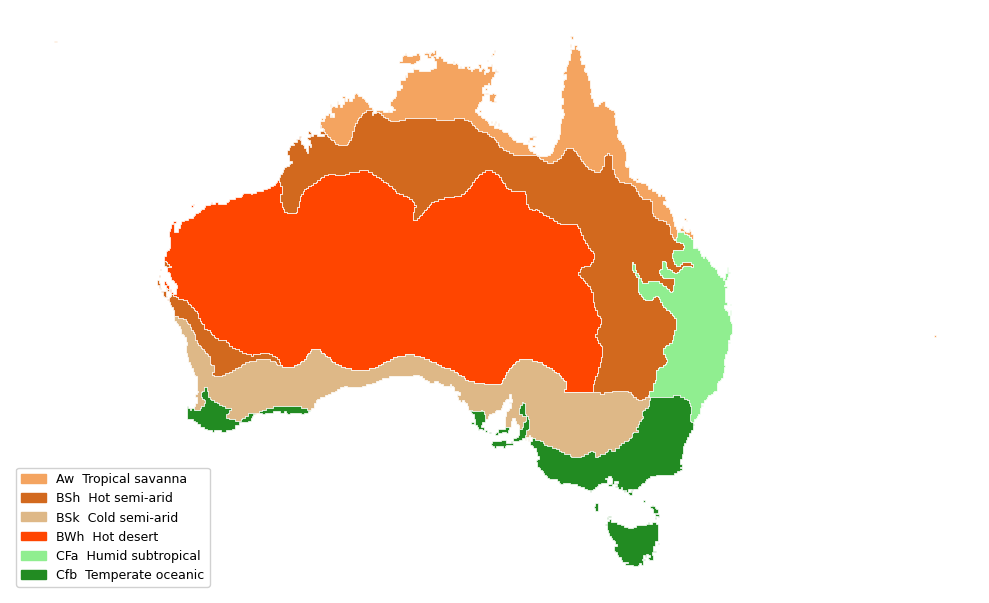

In [17]:
# Final Zones
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

ZONE_NAMES = {
    'Aw':  'Tropical savanna',
    'BSh': 'Hot semi-arid',
    'BSk': 'Cold semi-arid',
    'BWh': 'Hot desert',
    'CFa': 'Humid subtropical',
    'Cfb': 'Temperate oceanic',
}
ZONE_COLORS = {
    'Aw':  '#f4a460',
    'BSh': '#d2691e',
    'BSk': '#deb887',
    'BWh': '#ff4500',
    'CFa': '#90ee90',
    'Cfb': '#228b22',
}

gdf = gpd.read_file('Koppen_Australia_cleaned2.gpkg')
gdf['color'] = gdf['Name'].map(ZONE_COLORS)

fig, ax = plt.subplots(figsize=(10, 8))
gdf.plot(ax=ax, color=gdf['color'], edgecolor='white', linewidth=0.5)
patches = [mpatches.Patch(color=ZONE_COLORS[k], label=f'{k}  {ZONE_NAMES[k]}') for k in sorted(ZONE_COLORS)]
ax.legend(handles=patches, loc='lower left', fontsize=9, framealpha=0.9)
ax.axis('off')
plt.tight_layout()
plt.show()